In [24]:
import numpy as np
import torch
import pandas as pd
import os
import matplotlib.pyplot as plt
import random
import warnings

warnings.filterwarnings("ignore")

# Set the working directory to the project root directly
# Since this notebook is in scripts/, go to the parent directory
project_root = r'c:\Users\Timothee Delcourt\Documents\ETHZ-PhD\Coding\mars_currents_pinn'
os.chdir(project_root)
print("Project root directory:", os.getcwd())

import scripts.utils.utils as ut
from scripts.utils.data_masks import get_seasons_condition
import cmcrameri.cm as cmc
from scripts.utils.img_data_extractor import img2scalar_cmap

# import scripts.data_conversion as dc


plt.rcParams["font.family"] = 'DejaVu Serif' #"serif"
plt.rcParams.update({
    'figure.figsize': (4, 3),
    'font.family': 'DejaVu Serif',
    'lines.linewidth': 1.2,
    'lines.markersize': 3.5,
    'axes.labelsize': 10,
    'axes.linewidth': 1.2,
    'xtick.top': False,
    'ytick.right': False,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.minor.width': 0.8,
    'ytick.minor.width': 0.8,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'legend.fontsize': 10,
    'legend.frameon': False,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

Project root directory: c:\Users\Timothee Delcourt\Documents\ETHZ-PhD\Coding\mars_currents_pinn


In [5]:
df = pd.read_parquet('data/MAVEN_MSO_data.parquet', columns=['time'])

print(f"start time: {df['time'].min()}")
print(f"end time: {df['time'].max()}")
print(f"total duration in years: {(df['time'].max() - df['time'].min()).days / 365.25:.2f}")

start time: 2014-10-10 00:00:04
end time: 2025-02-15 00:00:00
total duration in years: 10.35


### figure style template

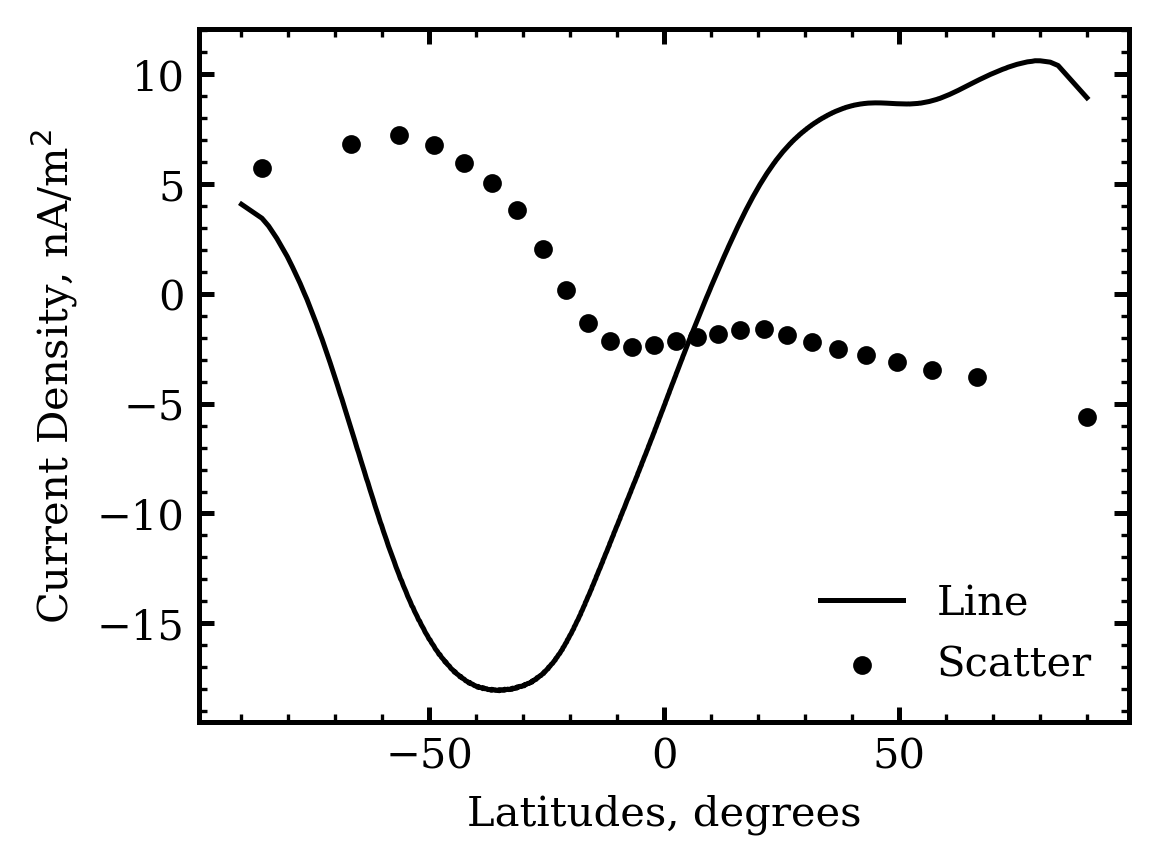

In [81]:


j = pd.read_csv('predictions/PINN_MSO_ensemble_models_1to30_150km_fibonacci_summer.csv')
j = j[(j.lon <= 0.1) & (j.lon >= -0.1)]

plt.rcParams["font.family"] = 'DejaVu Serif' #"serif"
plt.rcParams.update({
    'figure.figsize': (4, 3),
    'font.family': 'DejaVu Serif',
    'lines.linewidth': 1.2,
    'lines.markersize': 3.5,
    'axes.labelsize': 10,
    'axes.linewidth': 1.2,
    'xtick.top': True,
    'ytick.right': True,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.minor.width': 0.8,
    'ytick.minor.width': 0.8,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'legend.fontsize': 10,
    'legend.frameon': False,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

plt.figure()
plt.plot(j.lat,j.Jp,color='k',label='Line')
plt.scatter(j.lat[::20],j.Jt[::20],color='k',label='Scatter')
plt.ylabel(r"Current Density, nA/m$^2$")
plt.xlabel('Latitudes, degrees')
plt.legend(loc = 4)
plt.savefig('figures/figure_style_example.png')
plt.savefig('figures/figure_style_example.pdf')

### Make a density model

In [19]:
n_max_mean = np.mean([8,7.4,8.7,8.2,7.9,8.1,7.3,8.3])
print("n_max_mean:", n_max_mean)
print(f'{np.mean([8*1e4,7*1e4,9*1e4,1e5]):.2e}')

n_max_mean: 7.9875
8.50e+04


ls: 0
ls: 90
ls: 180
ls: 270


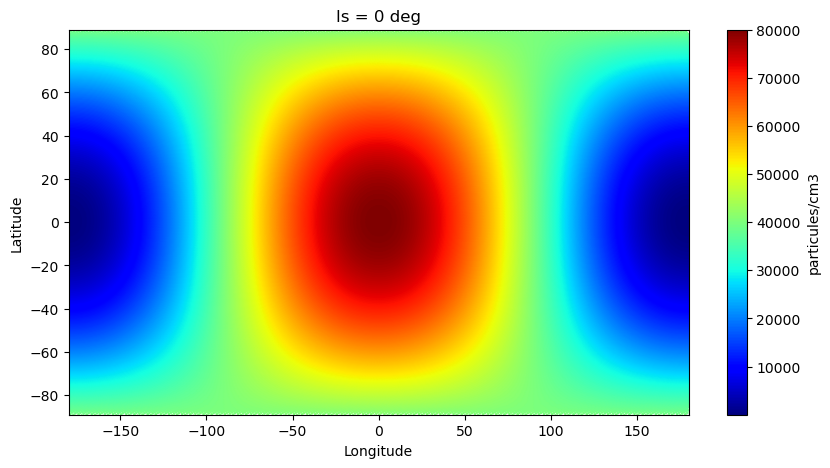

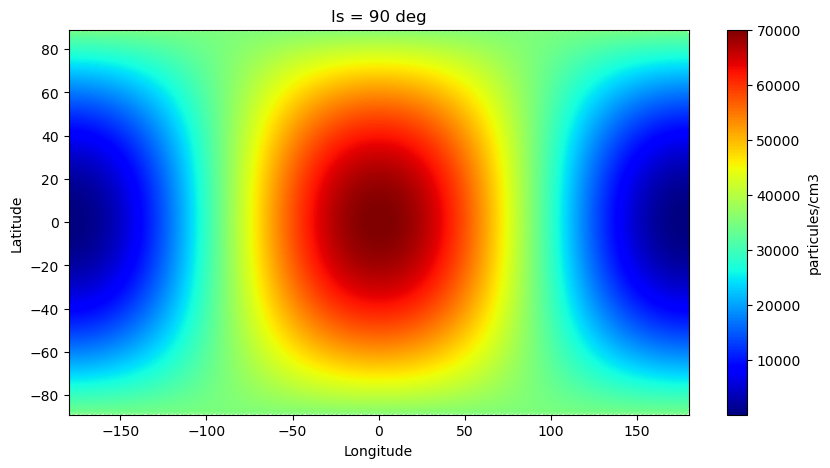

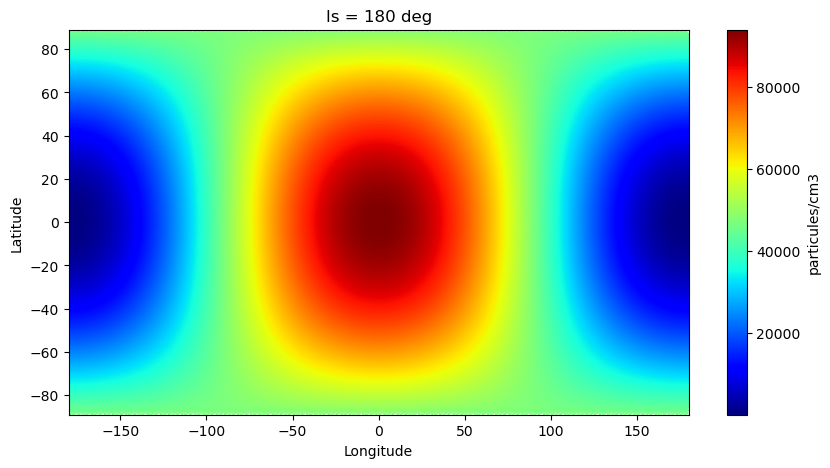

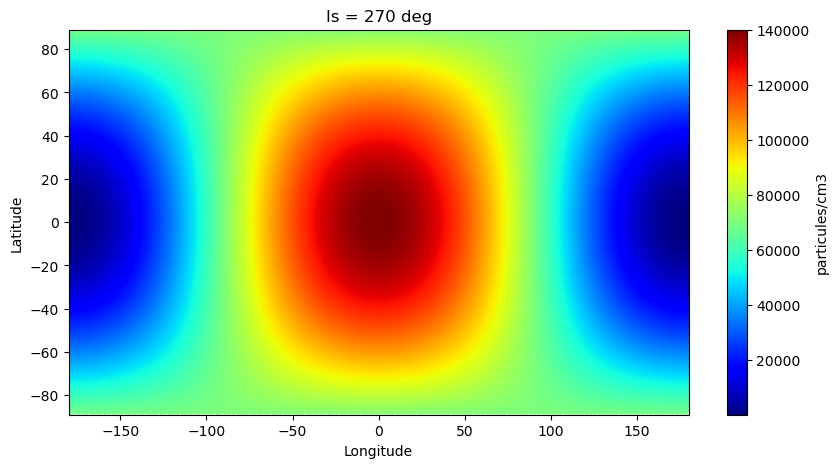

In [ ]:
df, _ = ut.fibonacci_sphere(samples = 900000,   alt = 150)
colat_rad = np.deg2rad(90-df.lat.values)
lon_rad = np.deg2rad(df.lon)

df_nmax = pd.DataFrame({'ls':[0,90,180,270],'n_max': [8*1e4,7*1e4,9*1e4,1e5]})
ls=0
n_max = df_nmax[df_nmax.ls==ls].n_max.values[0]

df['n'] = ((np.sin(colat_rad)*np.cos(lon_rad) * n_max) + n_max)/2

plt.figure(figsize=(10,5))
sc = plt.scatter(df.lon, df.lat, c=df.n, s=1, cmap='jet')
plt.colorbar(sc, label='particules/cm3')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim([-180,180])
plt.ylim([-89,89])

### Data Residuals vs season, with and without dust mask

In [ ]:

def compute_seasonal_mse(season, dust_mask = False):
    condition = get_seasons_condition(season)
    observation_mso = torch.load('data/observation_mso.pt')[condition]
    crustal_field_mso = torch.load('data/crustal_field_mso.pt')[condition]
    target = observation_mso - crustal_field_mso
    B_obs = torch.sqrt(target[:,0]**2 + target[:,1]**2 + target[:,2]**2).numpy()
    del observation_mso, crustal_field_mso
    try:
        prediction_df = pd.read_csv(f'predictions/data/PINN_MSO_ensemble_models_1to30_{season}_data_500km.csv',usecols=['Br','Bt','Bp'])
    except:
        prediction_df = pd.read_csv(f'predictions/data/PINN_MSO_ensemble_models_1to31_{season}_data_500km.csv',usecols=['Br','Bt','Bp'])
    B_pred = np.sqrt(prediction_df['Br'].values**2 + prediction_df['Bt'].values**2 + prediction_df['Bp'].values**2)
    del prediction_df
    mse = np.mean((B_obs-B_pred)**2)
    print(f'MSE = {mse:.1f}')
    return mse


seasons_str = ['spring','spring_summer','summer','summer_autumn','autumn','autumn_winter','winter','winter_spring']
seasons_ls = list(np.arange(0, 360, 45))
mses = []

for season in seasons_str:
    mses.append(compute_seasonal_mse(season))
    print(season+' computed')




MSE = 756.5
spring computed
MSE = 335.7
spring_summer computed
MSE = 398.1
summer computed
MSE = 319.4
summer_autumn computed
MSE = 496.5
autumn computed
MSE = 373.2
autumn_winter computed
MSE = 400.1
winter computed
MSE = 829.7
winter_spring computed


In [47]:
seasons_ls = list(np.arange(0, 360, 45))

def wrap(x):
    if x[0] == 0:
        # print(True)
        return list(np.array(x)-360) + x + list(np.array(x)+360)
    else:
        return x+x+x

season_str_2,mses_2, seasons_ls_2 = wrap(seasons_str),wrap(mses),wrap(seasons_ls)
rmse = np.sqrt(mses_2)

In [5]:
print(seasons_ls_2)

[-360, -315, -270, -225, -180, -135, -90, -45, 0, 45, 90, 135, 180, 225, 270, 315, 360, 405, 450, 495, 540, 585, 630, 675]


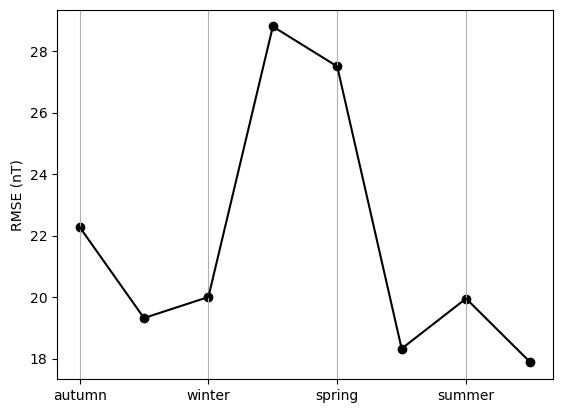

In [48]:
s = 4
plt.figure()
plt.plot(seasons_ls_2[s:s+8],rmse[s:s+8],color='k')
plt.scatter(seasons_ls_2[s:s+8],rmse[s:s+8],color='k')
plt.xticks(seasons_ls_2[s:s+8:2],season_str_2[s:s+8:2])
plt.ylabel('RMSE (nT)')
plt.grid(axis = 'x')
# plt.savefig(f'figures/residuals/RMSEvsSeason.png', dpi=300)

# plt.figure()
# plt.plot(seasons_ls_2[s:s+8],rmse[s:s+8],color='k')
# plt.scatter(seasons_ls_2[s:s+8],rmse[s:s+8],color='k')
# plt.xticks(seasons_ls_2[s:s+8:2],np.array(seasons_ls_2[s:s+8:2])%360)
# plt.ylabel('RMSE (nT)')
# plt.grid(axis = 'x')
# plt.savefig(f'figures/residuals/RMSEvsLS.png', dpi=300)

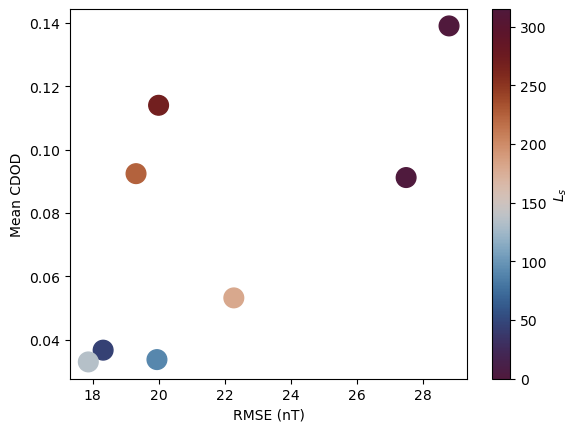

In [ ]:
# gray scale approach

from scripts.utils.img_data_extractor import gray_scale, img2scalar
seasons_ls = list(np.arange(0, 360, 45))
cdod = []
for ls in seasons_ls:
    if ls == 0:
        img1 = 'figures/residuals/dust_storms/raw/ls0_1.png'
        img2 = 'figures/residuals/dust_storms/raw/ls0_2.png'
        data = 1-np.mean([np.mean(gray_scale(img1)),np.mean(gray_scale(img1))])
    else:
        img = f'figures/residuals/dust_storms/raw/ls{ls}.png'
        data = 1-np.mean(gray_scale(img))
    cdod.append(data)
    # print(img)
    #convert to grayscale
    # data = np.dot(img[...,:3]/255, [0.299, 0.587, 0.114])
    # data = 1-data
    # print(np.mean(data))
    # pix.append(np.mean(data))
   

plt.figure()
plt.scatter(np.sqrt(mses), cdod,cmap=cmc.vikO,c=seasons_ls,s=200) #[1:]
plt.xlabel('RMSE (nT)')
plt.ylabel('Mean CDOD')
plt.colorbar(label=r'$L_s$')


In [ ]:
from scripts.utils.img_data_extractor import gray_scale, img2scalar
import importlib
import scripts.utils.img_data_extractor as ide
importlib.reload(ide)

cmap = 'YlOrBr'
seasons_ls = list(np.arange(0, 360, 45))
cdod = []
for ls in seasons_ls:
    if ls == 0:
        img1 = 'figures/residuals/dust_storms/raw/ls0_1.png'
        img2 = 'figures/residuals/dust_storms/raw/ls0_2.png'
        data = np.mean([np.mean(img2scalar(img1,cmap=cmap)),np.mean(img2scalar(img2,cmap=cmap))])
    else:
        img = f'figures/residuals/dust_storms/raw/ls{ls}.png'
        data = np.mean(img2scalar(img,cmap=cmap))
    cdod.append(data)
    # print(img)
    #convert to grayscale
    # data = np.dot(img[...,:3]/255, [0.299, 0.587, 0.114])
    # data = 1-data
    # print(np.mean(data))
    # pix.append(np.mean(data))
   

plt.figure()
plt.scatter(np.sqrt(mses), cdod,cmap=cmc.vikO,c=seasons_ls,s=200) #[1:]
plt.xlabel('RMSE (nT)')
plt.ylabel('Mean CDOD')
plt.colorbar(label=r'$L_s$')

UFuncTypeError: Cannot cast ufunc 'divide' output from dtype('float64') to dtype('int64') with casting rule 'same_kind'

### Data Residuals vs MSO position

In [14]:


# compute the residuals
def prepare_component_and_res(component, season = 'summer',day_side=False):

    condition = get_condition(season)
    observation_mso = torch.load('data/observation_mso.pt')[condition]
    crustal_field_mso = torch.load('data/crustal_field_mso.pt')[condition]
    target = observation_mso - crustal_field_mso
    B_obs = torch.sqrt(target[:,0]**2 + target[:,1]**2 + target[:,2]**2).numpy()
    del observation_mso, crustal_field_mso
    try:
        prediction_df = pd.read_csv(f'predictions/data/PINN_MSO_ensemble_models_1to30_{season}_data_500km.csv',usecols=['Br','Bt','Bp'])
    except:
        prediction_df = pd.read_csv(f'predictions/data/PINN_MSO_ensemble_models_1to31_{season}_data_500km.csv',usecols=['Br','Bt','Bp'])
    B_pred = np.sqrt(prediction_df['Br'].values**2 + prediction_df['Bt'].values**2 + prediction_df['Bp'].values**2)
    del prediction_df
    res = B_obs-B_pred

    input_sph = torch.load('data/position_mso_spherical.pt')[condition] # alt [km], lat [degree], lon [degree]
    x = input_sph[:,component]

    if day_side:
        deg_max = 90
        condition2 =  (input_sph[:,2] >= -deg_max) & (input_sph[:,2] <= deg_max)
        x, res = x[condition2], res[condition2]
    # print(season+' data loaded!')
    return x, res
    # alt, lat, lon = input_sph[:,0], input_sph[:,1], input_sph[:,2] 

    # if day_side:
    #     deg_max = 90
    #     condition2 =  (input_sph[:,2] >= -deg_max) & (input_sph[:,2] <= deg_max)
    #     alt, lat, lon, res = alt[condition2], lat[condition2], lon[condition2], res[condition2]

    # return alt, lat, lon, res



def compute_and_plot(component_str, step, save=False):
    
    if component_str == 'alt':
        component_col = 0
        unit = 'km'
        day_side = False
    elif component_str == 'lat':
        component_col = 1
        unit = 'degree'#, = UV angle'
        day_side = True
    elif component_str == 'lon':
        component_col = 2
        unit = r'degree'#, $\approx$ local time'
        day_side = False

    component = []
    res = []
    for season_i,season in enumerate(['spring','summer','autumn','winter']):
        component_i, res_i = prepare_component_and_res(component_col, season,day_side)
        component.append(component_i)
        res.append(res_i)
    component = np.concatenate(component)
    res = np.concatenate(res)

    comp_min, comp_max = min(component), max(component)
    bins = np.arange(comp_min,comp_max+step,step)
    mses = []
    print('Computing bins')
    for i in range(len(bins)-1):
        bin_mask = (component >= bins[i]) & (component < bins[i+1])
        mses.append(np.sqrt(np.mean(res[bin_mask]**2)))

    plt.figure()
    # plt.plot(bins[:-1]+step/2, mses, color='k')
    plt.scatter(bins[:-1]+step/2, mses, color='k')
    # if component_str == 'lon':
    #     plt.axvline(x=-90, color='k', linestyle='--',label=f'Terminator')
    #     plt.axvline(x=90, color='k', linestyle='--')
    #     plt.legend()
    # elif component_str == 'lat':
    #     lat = np.arange(-90,90,0.1)
    #     lat = np.deg2rad(lat)
    #     plt.plot(np.rad2deg(lat), min(mses)+np.exp(1-1/np.cos(lat))*(max(mses)-min(mses)), label='Scaled Chapman Function',color='k',linestyle='--')
    #     plt.legend()
    
    plt.xlabel(component_str+' ('+unit+')')
    plt.ylabel('RMSE (nT)')
    # plt.xlim(0,250)
    if save:
        plt.savefig(f'figures/residuals/RMSEvs'+component_str+'_v2.png', dpi=300)

    # plt.figure()
    # plt.hist(component, bins=bins, color='lightgray', alpha=0.5, density=False,log=True)
    # plt.xlabel(component_str+' ('+unit+')')
    # plt.ylabel('Density')
    # plt.show()


Computing bins


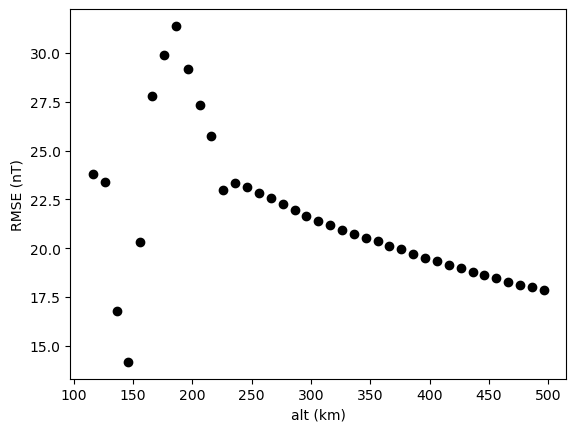

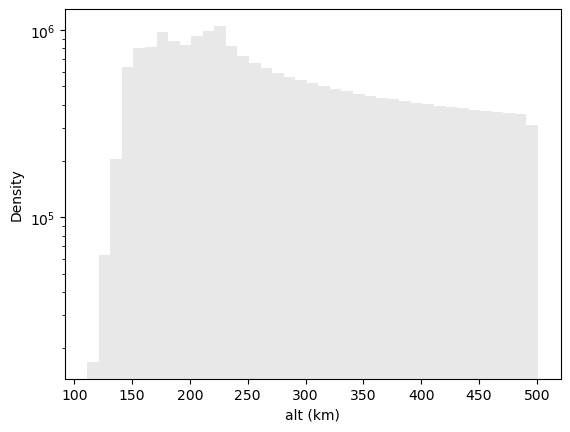

In [4]:
compute_and_plot('alt', step=10,save=False)

Computing bins


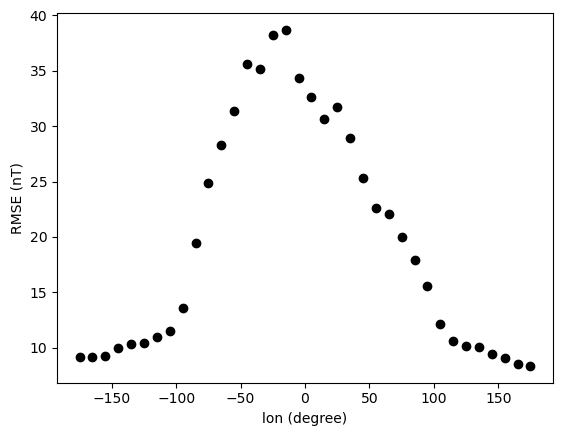

In [16]:
compute_and_plot('lon', step=10,save=True)

Computing bins


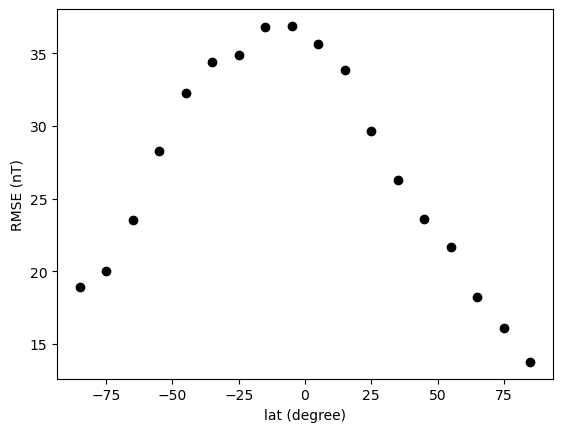

In [15]:
compute_and_plot('lat', step=10,save=True)

### J vs GCM

502


(-65.0, 65.0)

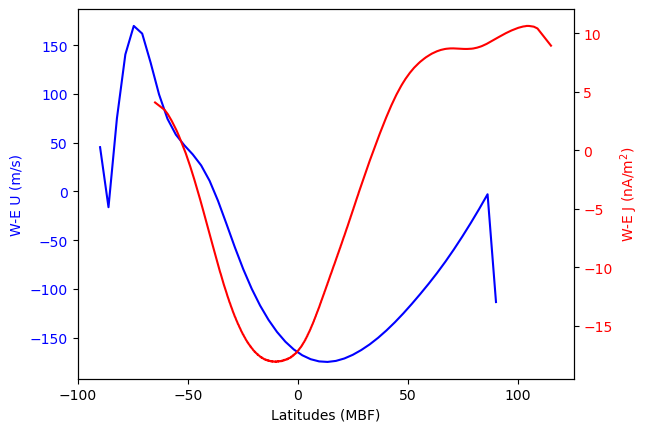

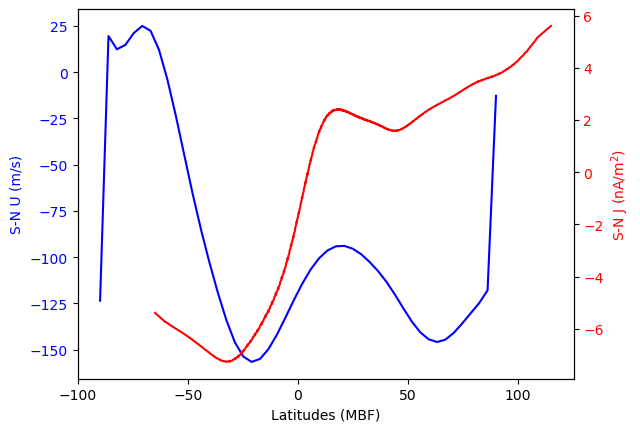

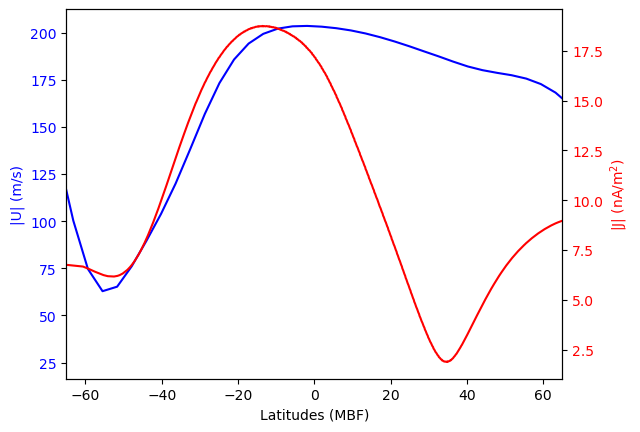

In [2]:
# def shift_lat_wrap(lat, delta):
#     lat = lat-delta
#     cond = lat < -90
#     lat[cond] = -90 + abs(abs(lat[cond])-90)
#     return lat
    

wind = pd.read_csv('data/GCM/winds_Ls90.csv')
j = pd.read_csv('predictions/PINN_MSO_ensemble_models_1to30_150km_fibonacci_summer.csv')
# j = pd.read_csv('predictions/PINN_MSO_ensemble_models_1to50_150km_fibonacci.csv')



# j = rotate_latitude_newdf(j,lat_shift_deg=25)

j = j[(j.lon <= 0.1) & (j.lon >= -0.1)]

print(len(j))
fig, ax1 = plt.subplots()
ax1.plot(wind.lat,wind.WE,color='b')
ax1.tick_params(axis='y',labelcolor='b')
ax1.set_ylabel('W-E U (m/s)',color='b')

ax2 = ax1.twinx()
# ax2.plot(lat_new,Jp_new,color='r')
ax2.plot(j.lat+25,j.Jp,color='r')
# ax2.plot(j.lat,j.Jp,color='r')
ax2.tick_params(axis='y',labelcolor='r')
ax2.set_ylabel(r"W-E J (nA/m$^2$)",color='r')

ax1.set_xlabel('Latitudes (MBF)')
# ax1.set_xlim(-65,65)

# plt.savefig('figures/JvsGCM/WE_Ls90.png',dpi=300)

fig, ax3 = plt.subplots()
ax3.plot(wind.lat,wind.NS,color='b')
ax3.tick_params(axis='y',labelcolor='b')
ax3.set_ylabel('S-N U (m/s)',color='b')

ax4 = ax3.twinx()
ax4.plot(j.lat+25,-j.Jt,color='r')
# ax4.plot(j.lat,-j.Jt,color='r')
ax4.tick_params(axis='y',labelcolor='r')
ax4.set_ylabel(r"S-N J (nA/m$^2$)",color='r')

ax3.set_xlabel('Latitudes (MBF)')
# ax3.set_xlim(-65,65)
# plt.savefig('figures/JvsGCM/SN_Ls90.png',dpi=300)

fig, ax5 = plt.subplots()
ax5.plot(wind.lat,np.sqrt(wind.NS**2 + wind.WE**2),color='b')
ax5.tick_params(axis='y',labelcolor='b')
ax5.set_ylabel('|U| (m/s)',color='b')

ax6 = ax5.twinx()
ax6.plot(j.lat+25,np.sqrt(j.Jt**2 + j.Jp**2),color='r')
# ax4.plot(j.lat,-j.Jt,color='r')
ax6.tick_params(axis='y',labelcolor='r')
ax6.set_ylabel(r"|J| (nA/m$^2$)",color='r')

ax5.set_xlabel('Latitudes (MBF)')
ax5.set_xlim(-65,65)
# plt.savefig('figures/JvsGCM/SN_Ls90.png',dpi=300)



493
494
497
500


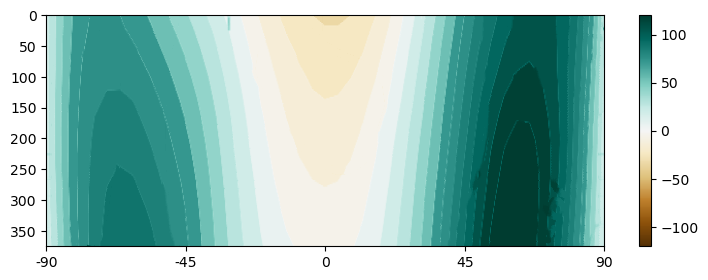

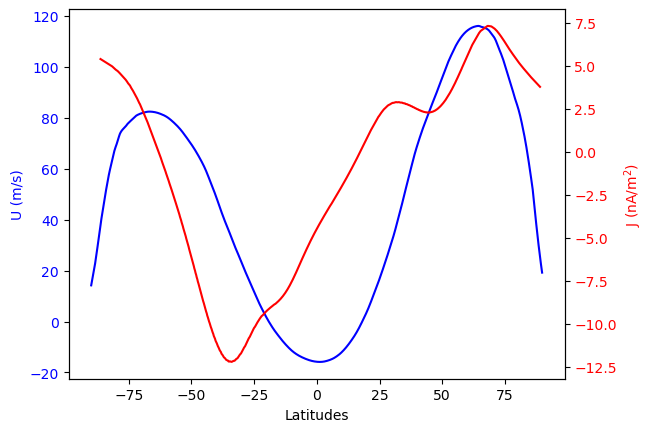

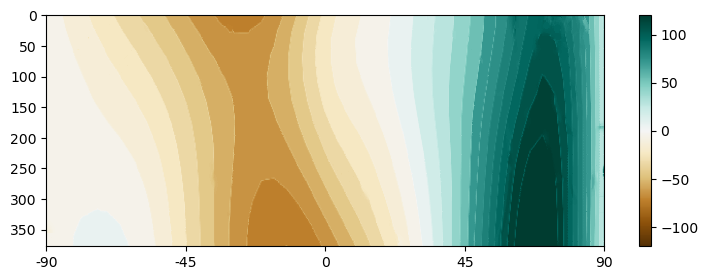

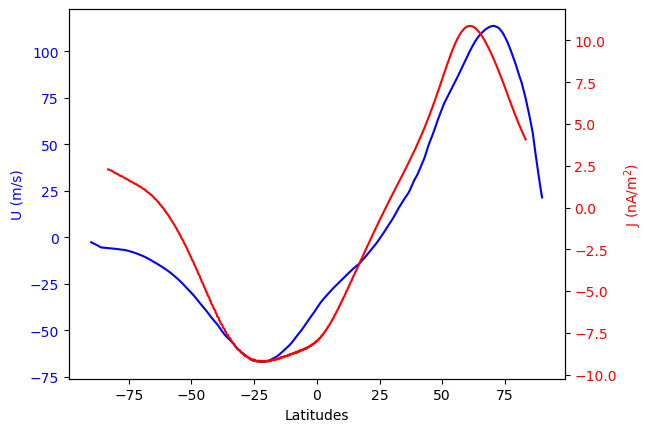

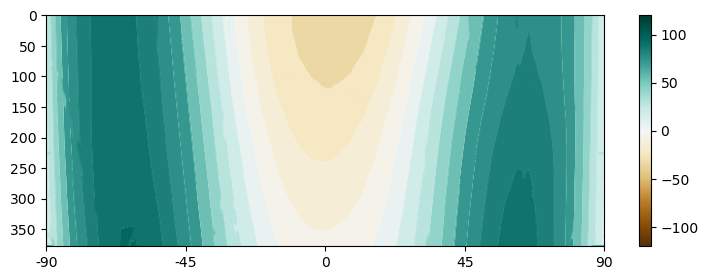

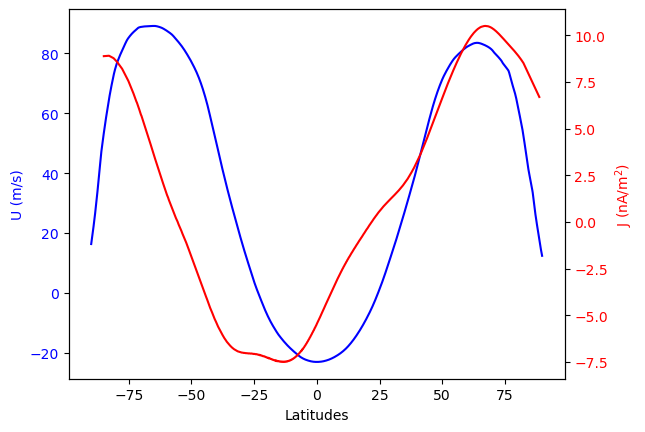

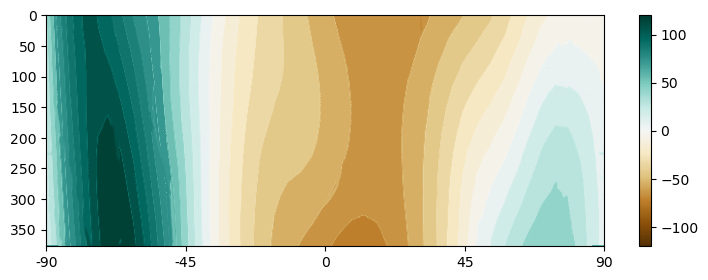

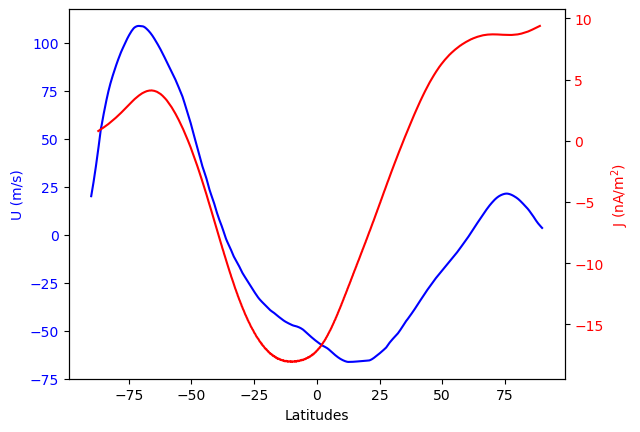

In [26]:
for season in ['autumn', 'winter', 'spring', 'summer']:

    wind = img2scalar_cmap(image = f"figures/JvsGCM/gcm2/{season}.png",
                    cmap = "BrBG",
                    vmin = -120,
                    vmax = 120)


    plt.figure(figsize=(9,3))
    plt.pcolor(wind,cmap="BrBG",vmin=-120,vmax=120)
    plt.xticks(ticks=np.linspace(0,wind.shape[1],5),labels=[-90,-45,0,45,90])
    plt.colorbar()
    plt.gca().invert_yaxis()

    zonal_wind = np.mean(wind,axis=0)
    def moving_average(data, window_size):
        return np.convolve(data, np.ones(window_size)/window_size, mode='same')
    zonal_wind = moving_average(zonal_wind, 50)
    lat = np.linspace(-90,90,endpoint=False,num=len(zonal_wind))


    # j = pd.read_csv(f'predictions/PINN_MSO_ensemble_models_1to30_150km_fibonacci_{season}.csv')
    j = pd.read_csv(f'predictions/PINN_LT_150km_fibonacci_{season}.csv')
    j = j[(j.lon <= 0.1) & (j.lon >= -0.1)]
    j = j.sort_values(by='lat')


    print(len(j))
    fig, ax1 = plt.subplots()
    ax1.plot(lat,zonal_wind,color='b')
    ax1.tick_params(axis='y',labelcolor='b')
    ax1.set_ylabel('U (m/s)',color='b')

    ax2 = ax1.twinx()
    # ax2.plot(j.lat+25,j.Jp,color='r')
    ax2.plot(j.lat,j.Jp,color='r')
    ax2.tick_params(axis='y',labelcolor='r')
    ax2.set_ylabel(r"J (nA/m$^2$)",color='r')

    # ax1.set_xlabel('Latitudes (MBF)')
    ax1.set_xlabel('Latitudes')
    # ax1.set_xlim(-65,65)

    plt.savefig(f'figures/JvsGCM/gcm2_{season}.png',dpi=300)


### Data Residuals vs Bcrust

In [ ]:
# def field_cart_to_spher(Bx,By,Bz,lat_deg=None, lon_deg=None,colat_rad=None,lon_rad=None,device=None):
#     '''Converts magnetic field components from cartesian to spherical coordinates. '''
#     if (colat_rad is None) & (lon_rad is None):
#         try:
#             colat_rad = np.pi/2 - np.radians(lat_deg)
#             lon_rad = np.radians(lon_deg)
#         except:
#             print('Please provide (co-)latitude and longitude')
#             return
#     if device is not None:
#         colat = torch.tensor(colat_rad, dtype=torch.float32, device=device)
#         lon = torch.tensor(lon_rad, dtype=torch.float32, device=device)
#     else:
#         colat = torch.tensor(colat_rad, dtype=torch.float32)
#         lon = torch.tensor(lon_rad, dtype=torch.float32)
#     Br = Bx*torch.sin(colat)*torch.cos(lon) + By*torch.sin(colat)*torch.sin(lon) + Bz*torch.cos(colat)
#     Bt = Bx*torch.cos(colat)*torch.cos(lon) + By*torch.cos(colat)*torch.sin(lon) - Bz*torch.sin(colat)
#     Bp = -Bx*torch.sin(lon) + By*torch.cos(lon)
#     return Br, Bt, Bp

In [5]:
# compute the residuals
def prepare_B_crust_and_res(season = 'summer',alt_max=None,day_side=False):

    condition = get_condition(season)
    observation_mso = torch.load('data/observation_mso.pt')[condition]
    crustal_field_mso = torch.load('data/crustal_field_mso.pt')[condition]
    target = observation_mso - crustal_field_mso
    B_obs = torch.sqrt(target[:,0]**2 + target[:,1]**2 + target[:,2]**2).numpy()
    B_crust = torch.sqrt(crustal_field_mso[:,0]**2 + crustal_field_mso[:,1]**2 + crustal_field_mso[:,2]**2).numpy()
    del observation_mso, crustal_field_mso
    try:
        prediction_df = pd.read_csv(f'predictions/data/PINN_MSO_ensemble_models_1to30_{season}_data_500km.csv',usecols=['Br','Bt','Bp'])
    except:
        prediction_df = pd.read_csv(f'predictions/data/PINN_MSO_ensemble_models_1to31_{season}_data_500km.csv',usecols=['Br','Bt','Bp'])
    B_pred = np.sqrt(prediction_df['Br'].values**2 + prediction_df['Bt'].values**2 + prediction_df['Bp'].values**2)
    del prediction_df
    res = B_obs-B_pred

    if day_side or (alt_max is not None):
        input_sph = torch.load('data/position_mso_spherical.pt')[condition]
        # sample only dayside
        if day_side:
            deg_max = 90
            condition2 =  (input_sph[:,2] >= -deg_max) & (input_sph[:,2] <= deg_max)
            B_crust, res = B_crust[condition2], res[condition2]
        # and low altitude
        if alt_max is not None:
            condition3 = (input_sph[:,0] <= alt_max)
            B_crust, res = B_crust[condition3], res[condition3]
        
    return B_crust, res
# print(len(res))
# print(max(B_crust))
# res = np.mean((B_obs-B_pred)**2)

In [85]:
# for season_i,season in enumerate(['spring','summer','autumn','winter']):
#     condition = get_condition(season)
#     input_sph = torch.load('data/position_mso_spherical.pt')[condition]
#     print(input_sph.shape)
#     B_crust, _ = prepare_B_crust_and_res(season, alt_max=150)
#     input_sph = input_sph[B_crust <= 105]
#     print(input_sph.shape)
#     for k,i in enumerate(['r','t','p']):
#         # print(f'min {i}: {min(input_sph[:,k])}')
#         # print(f'max {i}: {max(input_sph[:,k])}')
#         print(f'mean {i}: {torch.mean(input_sph[:,k])}')
#         print(f'median {i}: {torch.median(input_sph[:,k])}')
#         print('')
        # print(f'Mean B : {np.mean(B_crust)}')

In [7]:
# Residuals vs B_crust seasons merged, part 1
B_crust = []
res = []
for season_i,season in enumerate(['spring','summer','autumn','winter']):
    B_crust_i, res_i = prepare_B_crust_and_res(season)
    B_crust.append(B_crust_i)
    res.append(res_i)
B_crust = np.concatenate(B_crust)
res = np.concatenate(res)

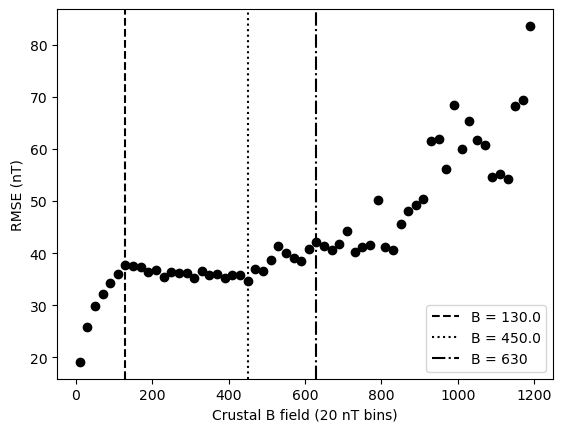

In [8]:
# Residuals vs B_crust seasons merged, part 2
# alt_max = 150
step = 20
b_max = 1200#max(B_crust)
B_bins = np.arange(0,b_max+step,step)
B_mses = []
for i in range(len(B_bins)-1):
    bin_mask = (B_crust >= B_bins[i]) & (B_crust < B_bins[i+1])
    B_mses.append(np.sqrt(np.mean(res[bin_mask]**2)))

plt.figure()
# plt.grid()
# plt.plot(B_bins[:-1]+step/2, B_mses,label=season, color='k')
plt.scatter(B_bins[:-1]+step/2, B_mses, color='k')
plt.xlabel(f'Crustal B field ({step} nT bins)')
plt.ylabel('RMSE (nT)')
plt.axvline(x=B_bins[6]+step/2, color='k', linestyle='--',label=f'B = {B_bins[6]+step/2:.1f}')
plt.axvline(x=B_bins[22]+step/2, color='k', linestyle=':',label=f'B = {B_bins[22]+step/2:.1f}')
plt.axvline(x=630, color='k', linestyle='-.',label=f'B = {630}')
plt.legend()
# plt.xlim(0,250)
# plt.savefig(f'figures/residuals/RMSEvsBcrust_v2.png', dpi=300)

# plt.figure()
# plt.hist(B_crust, bins=B_bins, color='lightgray', alpha=0.5, density=False,log=True)
# plt.xlabel('B bins (nT)')
# plt.ylabel('Density')
# plt.show()

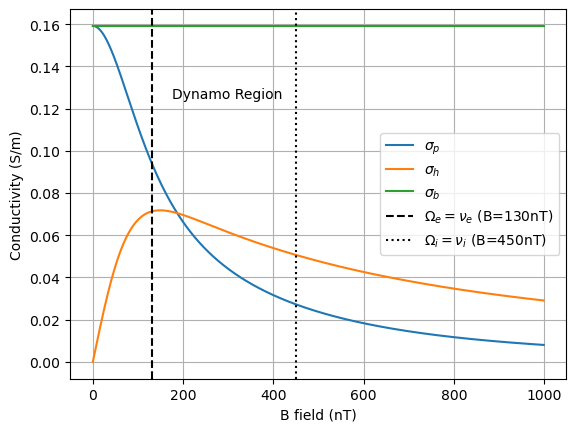

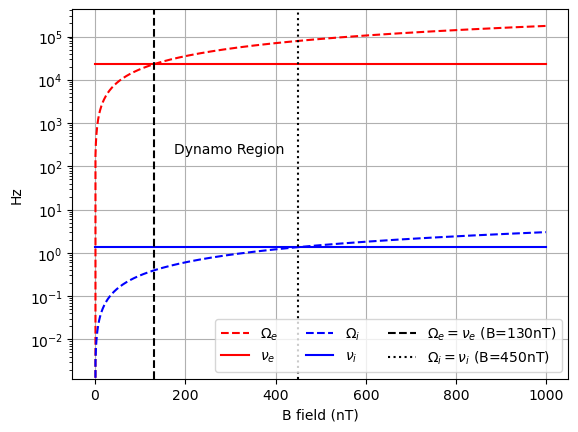

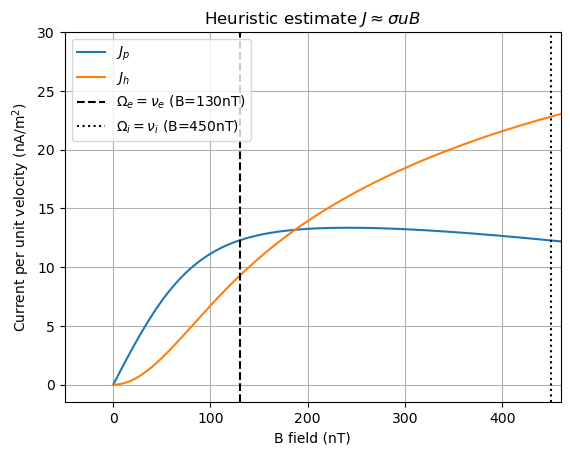

In [18]:
# elementary mass
m_e = 9.11e-31  # kg
m_p = 1.67e-27  # kg
# m_i = 5.314e-23 - m_e
m_i = 32*1.660539066601e-27 - m_e
e = 1.60217646e-19 # C
# B = 770*1e-9  # T
B = np.array(range(1000))*1e-9  # T
W_e = e*B/m_e # rad/s, devide by 2pi to get cycles per second (e.g., dynamo layer plot)
W_i = e*B/m_i # rad/s
n = 1e11 # m-3
f_e = 2.28e4 # Hz
# f_i = 1.356e-3 # Hz
f_i = 1.35684
# f_i = 1.356e0 # Hz

sigma_p = ((f_e/((f_e**2)+(W_e**2))) + (m_e/m_i)*(f_i/((f_i**2)+(W_i**2)))) * (n*(e**2)/m_e) #*B
sigma_h = ((W_e/((f_e**2)+(W_e**2))) + (m_e/m_i)*(W_i/((f_i**2)+(W_i**2)))) * (n*(e**2)/m_e) #*B
sigma_b = ((1/f_e) + (m_e/m_i)*(1/f_i)) * (n*(e**2)/m_e) #*B

plt.figure()
plt.plot(B*1e9,sigma_p,label=r'$\sigma_p$')
plt.plot(B*1e9,sigma_h,label=r'$\sigma_h$')
plt.plot(B*1e9,sigma_b*np.ones_like(B),label=r'$\sigma_b$')
x1 = B[np.argmin(abs(W_e - f_e))]*1e9
x2 = B[np.argmin(abs(W_i - f_i))]*1e9
plt.axvline(x=x1, color='k', linestyle='--',label=r'$\Omega_e = \nu_e$'+f' (B={int(x1)}nT)')
plt.axvline(x=x2, color='k', linestyle=':',label=r'$\Omega_i = \nu_i$'+f' (B={int(x2)}nT)')
plt.xlabel('B field (nT)')
plt.ylabel('Conductivity (S/m)')
plt.grid()
plt.legend(ncol=1)
plt.text(x=175,y=0.125,s="Dynamo Region")
# plt.savefig(f'figures/SigmavsBcrust.png', dpi=300)
# print(f'Argmax of sigma_h : B = {int(B[sigma_h == max(sigma_h)]*1e9)} nT')
# print(f'Argmax of sigma_p : B = {int(B[sigma_p == max(sigma_p)]*1e9)} nT')


plt.figure()
plt.plot(B*1e9,W_e,label=r'$\Omega_e$',color='r',linestyle='--')
plt.plot(B*1e9,np.ones_like(B)*f_e,label=r'$\nu_e$',color='r')
plt.plot(B*1e9,W_i,label=r'$\Omega_i$',color='b',linestyle='--')
plt.plot(B*1e9,np.ones_like(B)*f_i,label=r'$\nu_i$',color='b')
plt.axvline(x=x1, color='k', linestyle='--',label=r'$\Omega_e = \nu_e$'+f' (B={int(x1)}nT)')
plt.axvline(x=x2, color='k', linestyle=':',label=r'$\Omega_i = \nu_i$'+f' (B={int(x2)}nT)')
plt.xlabel('B field (nT)')
plt.ylabel('Hz')
plt.grid()
plt.yscale('log')
plt.legend(loc =4, ncol = 3)
plt.text(x=175,y=200,s="Dynamo Region")
# plt.savefig(f'figures/FreqvsBcrust.png', dpi=300)




plt.figure()
plt.plot(B*1e9,sigma_p*B*1e9,label=r'$J_p$')
plt.plot(B*1e9,sigma_h*B*1e9,label=r'$J_h$')
# plt.plot(B*1e9,sigma_b*B*1e9,label=r'$J_b$')
x1 = B[np.argmin(abs(W_e - f_e))]*1e9
x2 = B[np.argmin(abs(W_i - f_i))]*1e9
plt.axvline(x=x1, color='k', linestyle='--',label=r'$\Omega_e = \nu_e$'+f' (B={int(x1)}nT)')
plt.axvline(x=x2, color='k', linestyle=':',label=r'$\Omega_i = \nu_i$'+f' (B={int(x2)}nT)')
plt.xlabel('B field (nT)')
plt.ylabel(r'Current per unit velocity (nA/m$^2$)')
plt.grid()
plt.legend()
plt.title(r"Heuristic estimate $J \approx \sigma u B$")
plt.xlim(right=460)
plt.ylim(top=30)
plt.savefig(f'figures/JvsBcrust.png', dpi=300)


# plt.figure()
# plt.plot(B*1e9,sigma_h/sigma_p)
# x1 = B[np.argmin(abs(W_e - f_e))]*1e9
# x2 = B[np.argmin(abs(W_i - f_i))]*1e9
# plt.axvline(x=x1, color='k', linestyle='--',label=r'$\Omega_e = \nu_e$'+f' (B={int(x1)}nT)')
# plt.axvline(x=x2, color='k', linestyle=':',label=r'$\Omega_i = \nu_i$'+f' (B={int(x2)}nT)')
# plt.xlabel('B field (nT)')
# plt.ylabel(r'$\sigma_h$/$\sigma_p$')
# plt.grid()
# plt.legend()
# plt.savefig(f'figures/JvsBcrust.png', dpi=300)

# print(f'Argmax of J_h : B = {int(B[sigma_h*B == max(sigma_h*B)]*1e9)} nT')
# print(f'Argmax of J_p : B = {int(B[sigma_p*B == max(sigma_p*B)]*1e9)} nT')


In [186]:
# print('B = 130 nT')
# f_e = (130e-9)*e/m_e
# print(f_e)
# f_i = (130e-9)*e/m_i
# print(f'{f_i:.1e}')
# print('')
# print('B = 450 nT')
# f_e = (450e-9)*e/m_e
# print(f_e)
f_i = (450e-9)*e/m_i
# print(f'{f_i}')
# print('')
# print('B = 770 nT')
# f_e = (770e-9)*e/m_e
# print(f'{f_e:.1e}')
# f_i = (770e-9)*e/m_i
# print(f'{f_i}')

m_co2 = 1.99261e-26 + m_i
m_o = ((m_i + m_e)/2) - m_e
m_no = m_o + 2.325e-26
m_co = m_o + 1.99261e-26

print(f'Assuming a frequency of {f_i} Hz')
print(f'Limit B of CO2+: {1e9*m_co2*1.36/e} nT')
print(f'Limit B of O+: {1e9*m_o*1.36/e} nT')
print(f'Limit B of NO+: {1e9*m_no*1.36/e} nT')
print(f'Limit B of CO+: {1e9*m_co*1.36/e} nT')
print(f'Limit B of CO+: {1e9*m_p*1.36/e} nT')


Assuming a frequency of 1.3568480982842666 Hz
Limit B of CO2+: 620.1870998558768 nT
Limit B of O+: 225.51879915423146 nT
Limit B of NO+: 422.87533752204644 nT
Limit B of CO+: 394.66056772072255 nT
Limit B of CO+: 14.175716949430154 nT


In [187]:
b = 450e-9
mu_o = 1.25663706127e-6
eps_o = 8.8541878188e-12
k_b = 1.3806503e-23
n = 1e11
T = (b**2)/(2*mu_o*n*k_b)
print(T)

plasma_freq = np.sqrt(1e11*(e**2)/(m_e*eps_o))
print(plasma_freq)

58358.144673499264
17839258.265914164


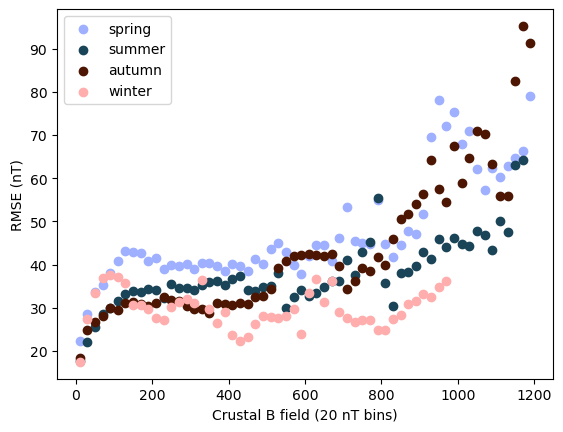

In [ ]:
# Residuals vs B_crust seasons separate
cmap = cmc.berlin([0,0.33,0.66,1])
# alt_max = 150
step = 20
plt.figure()
for season_i,season in enumerate(['spring','summer','autumn','winter']):
    B_crust, res = prepare_B_crust_and_res(season)
    b_max = max(B_crust)
    B_bins = np.arange(0,b_max+step,step)
    B_mses = []
    for i in range(len(B_bins)-1):
        bin_mask = (B_crust >= B_bins[i]) & (B_crust < B_bins[i+1])
        # if sum(bin_mask) >= 10:
        B_mses.append(np.sqrt(np.mean(res[bin_mask]**2)))
        # else:
        #     B_mses.append(np.nan)

    plt.scatter(B_bins[:-1]+step/2, B_mses,label=season, color=cmap[season_i])
plt.legend(loc=2)
plt.xlabel(f'Crustal B field ({step} nT bins)')
plt.ylabel('RMSE (nT)')
# plt.xscale('log')
# plt.xscale('symlog', linthresh=100)
plt.savefig(f'figures/residuals/RMSEvsBcrust.png', dpi=300)
# plt.savefig(f'figures/residuals/RMSEvsBcrust_dayside_max{alt_max}km.png', dpi=300)
# plt.savefig(f'figures/residuals/RMSEvsBcrust_dayside.png', dpi=300)





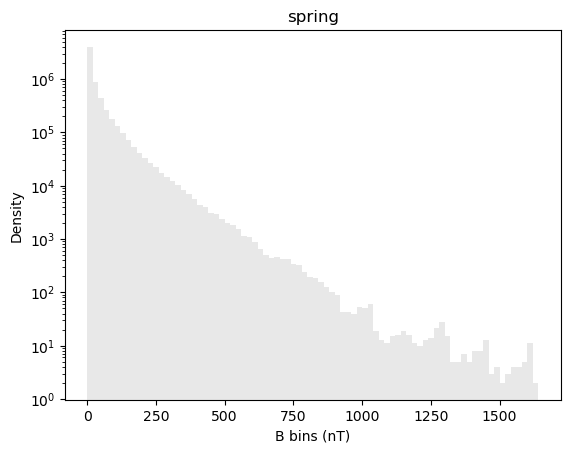

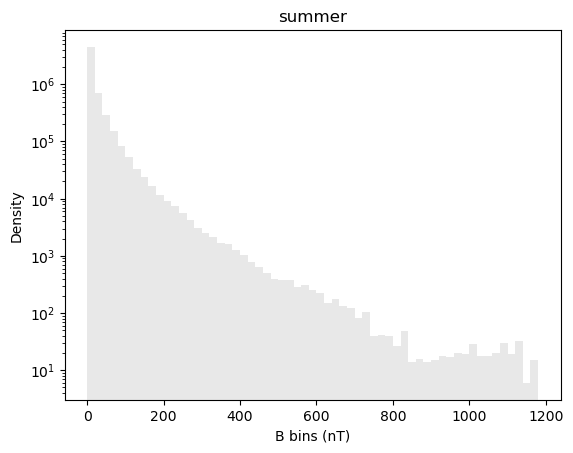

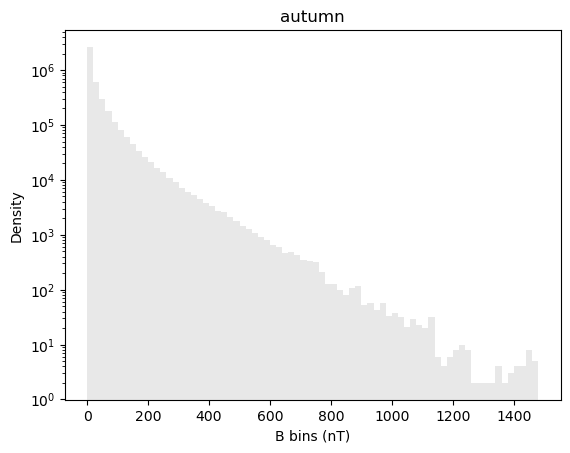

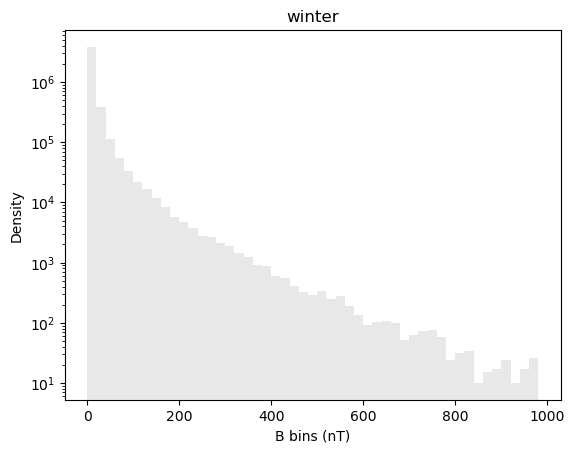

In [108]:
for season_i,season in enumerate(['spring','summer','autumn','winter']):
    B_crust, _ = prepare_B_crust_and_res(season)
    step = 20
    b_max = max(B_crust)
    B_bins = np.arange(0,b_max+step,step)
    plt.figure()
    plt.hist(B_crust, bins=B_bins, color='lightgray', alpha=0.5, density=False,log=True)
    plt.xlabel('B bins (nT)')
    plt.ylabel('Density')
    plt.title(season)
    plt.show()

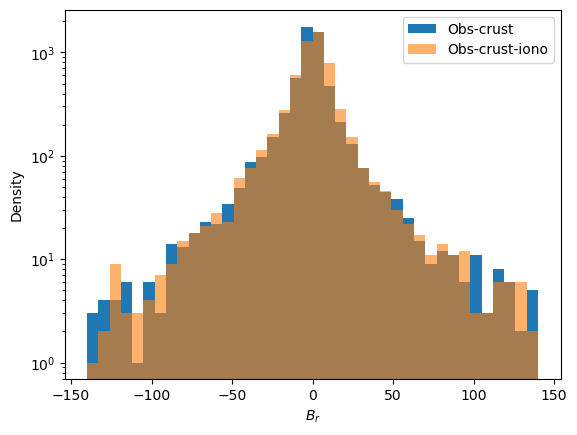

In [ ]:
# Br residuals histogram

observation_mso = torch.load('data/observation_mso.pt')[condition]
input_sph = torch.load('data/position_mso_spherical.pt')[condition]
Br_obs, _, _ = field_cart_to_spher(observation_mso[:,0],observation_mso[:,1],observation_mso[:,2], lat_deg=input_sph[:,1], lon_deg = input_sph[:,2])
del observation_mso, input_sph
Br_iono = pd.read_csv('predictions/PINN_MSO_ensemble_models_1to30_summer_data_500km.csv',usecols=['Br']).values
Br_iono = torch.tensor(Br_iono)
Br_iono = Br_iono[:,0]
Br_crust = torch.load('data/crustal_field_mso.pt')[condition][:,0]

Br_obs_0, Br_crust_0, Br_iono_0 = Br_obs[::1000], Br_crust[::1000], Br_iono[::1000]
# n_bins = int(2*len(Br_obs_0)**(1/3))
# n_bins = int(np.sqrt(len(Br_crust)))
n_bins = 40
lim = 140

plt.figure()
# plt.hist(Br_obs_0, density=True, log = True, bins = n_bins,label='Obs')
plt.hist(Br_obs_0-Br_crust_0, log = True, bins = n_bins,label='Obs-crust',alpha=1, range = (-lim,lim))
plt.hist(Br_obs_0-Br_crust_0-Br_iono_0, log = True, bins = n_bins,label='Obs-crust-iono',alpha=0.6, range = (-lim,lim))
plt.xlabel(r"$B_r$")
plt.ylabel('Density')
# plt.xlim(-100,100)
plt.legend()
plt.show()

### Test that j tends to u when b is random and isotropic

In [ ]:
def sample_unit_sphere(n):
    x = np.random.normal(size=(n,3))
    x /= np.linalg.norm(x, axis=1, keepdims=True)
    return x

u = np.array([1,1,1]) # fixed vector
b = sample_unit_sphere(10000) # random vectors on unit sphere
cross_products = []
u_perpendiculars = []
for line in range(len(b)):
    cross_products.append(np.cross(u, b[line,:]))
    u_perpendicular = np.cross(b[line,:], cross_products[-1])
    # u_perpendicular must have the length of the projection of u onto u_perpendicular
    proj_u_on_b = (np.dot(u, b[line,:]) / np.dot(b[line,:], b[line,:])) * b[line,:]
    u_perp_vector = u - proj_u_on_b
    u_perpendicular = (np.linalg.norm(u_perp_vector) / np.linalg.norm(u_perpendicular)) * u_perpendicular
    u_perpendiculars.append(u_perpendicular)
cross_products = np.array(cross_products)
print(np.mean(cross_products, axis=0))
print('---')
u_perpendiculars = np.array(u_perpendiculars)
print(np.mean(u_perpendiculars, axis=0))
print(f'Norm of u: {np.linalg.norm(u)}')
print(f'Norm of mean u_perpendicular: {np.linalg.norm(np.mean(u_perpendiculars, axis=0))}')

[ 0.0074116  -0.00635113 -0.00106048]
---
[0.67641786 0.66599189 0.66708745]
Norm of u: 1.1547005383792515
Norm of mean u_perpendicular: 1.1602120419103006


### compare B_crust_avg and J

In [25]:
import pandas as pd

def get_B_and_J(season):
    
    crustal_field = pd.read_csv(f'predictions/crustal_field_rotation_avg_{season}_150km_fibonacci.csv')
    print(crustal_field.shape)
    if season == 'winter':
        current_field = pd.read_csv(f'predictions/PINN_MSO_ensemble_models_1to30_150km_fibonacci_winter.csv')
    elif season == 'summer':
        current_field = pd.read_csv(f'predictions/PINN_MSO_ensemble_models_1to30_150km_fibonacci_summer.csv')
    elif season == 'autumn':
        current_field = pd.read_csv(f'predictions/PINN_MSO_ensemble_models_1to31_150km_fibonacci_autumn.csv')
    elif season == 'spring':
        current_field = pd.read_csv(f'predictions/PINN_MSO_ensemble_models_1to30_150km_fibonacci_spring.csv')

    deg_max = 85
    condition = (crustal_field['lat'] <= 60) & (crustal_field['lat'] >= -60) & (crustal_field['lon'] >= -deg_max) & (crustal_field['lon'] <= deg_max)
    # condition = (crustal_field['lon'] >= -95) & (crustal_field['lon'] <= 95)

    crustal_field = crustal_field[condition]
    current_field = current_field[condition]
    print(crustal_field.shape)
    Jtotal = 0.0
    for i in ['x','y','z']:
        Jtotal += (current_field['J'+i].values)**2
    Jtotal = np.sqrt(Jtotal)
    current_field['Jtotal'] = Jtotal

    cos_lat = np.cos(np.deg2rad(crustal_field['lat'].values))
    crustal_field['B_chapman'] = (crustal_field['B'].values) * np.exp(1-1/cos_lat)
    # normalize to fit from 0 to 1 ---------------------------------------------------
    # crustal_field['B_chapman'] = (crustal_field['B_chapman'] - min(crustal_field['B_chapman'])) / (max(crustal_field['B_chapman']) - min(crustal_field['B_chapman']))
    # --------------------------------------------------------------------------------
    # J_h = np.sqrt(current_field['Jp'].values**2 + current_field['Jt'].values**2)

    return crustal_field['B_chapman'].values, current_field['Jtotal'].values
    return crustal_field['B'].values, current_field['Jtotal'].values
    B_h = np.sqrt(crustal_field['Bp'].values**2 + crustal_field['Bt'].values**2)
    B_h_scaled = B_h * np.exp(1-1/cos_lat)
    return B_h_scaled, current_field['Jp'].values

# plt.xscale('log')

In [18]:
# season = 'spring'  # 'spring', 'autumn', None, 'summer', 'winter'
B_scaled_seasons = []
J_seasons = []
for season in ['spring', 'autumn', 'summer', 'winter']:
    B_scaled, J = get_B_and_J(season)
    B_scaled_seasons.append(B_scaled)
    J_seasons.append(J)

B_scaled = np.concatenate(B_scaled_seasons)
J = np.concatenate(J_seasons)
J = abs(J)

(900000, 7)
(368059, 7)
(900000, 7)
(368059, 7)
(900000, 7)
(368059, 7)
(900000, 7)
(368059, 7)


(1472236,) (1472236,)
Correlation coefficient between J and B crustal (Chapman corrected) up to 20 nT: 0.8789547910506292


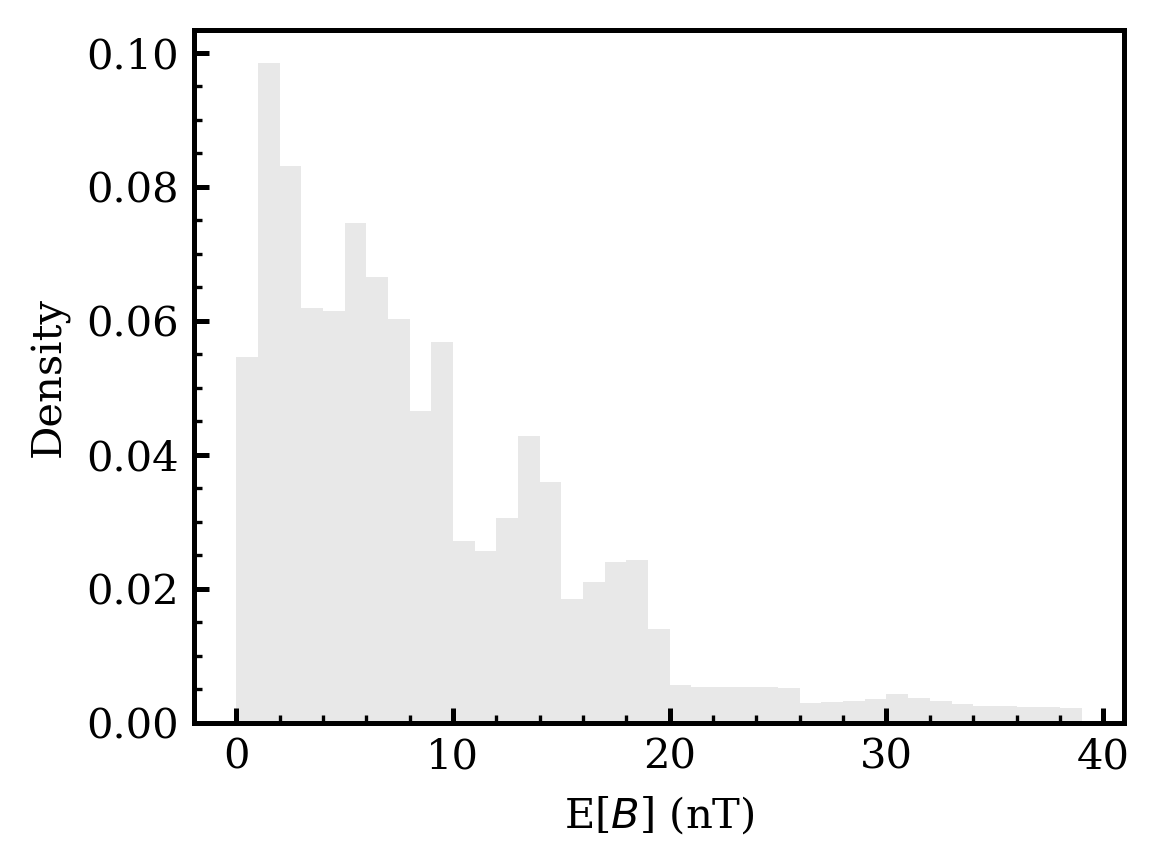

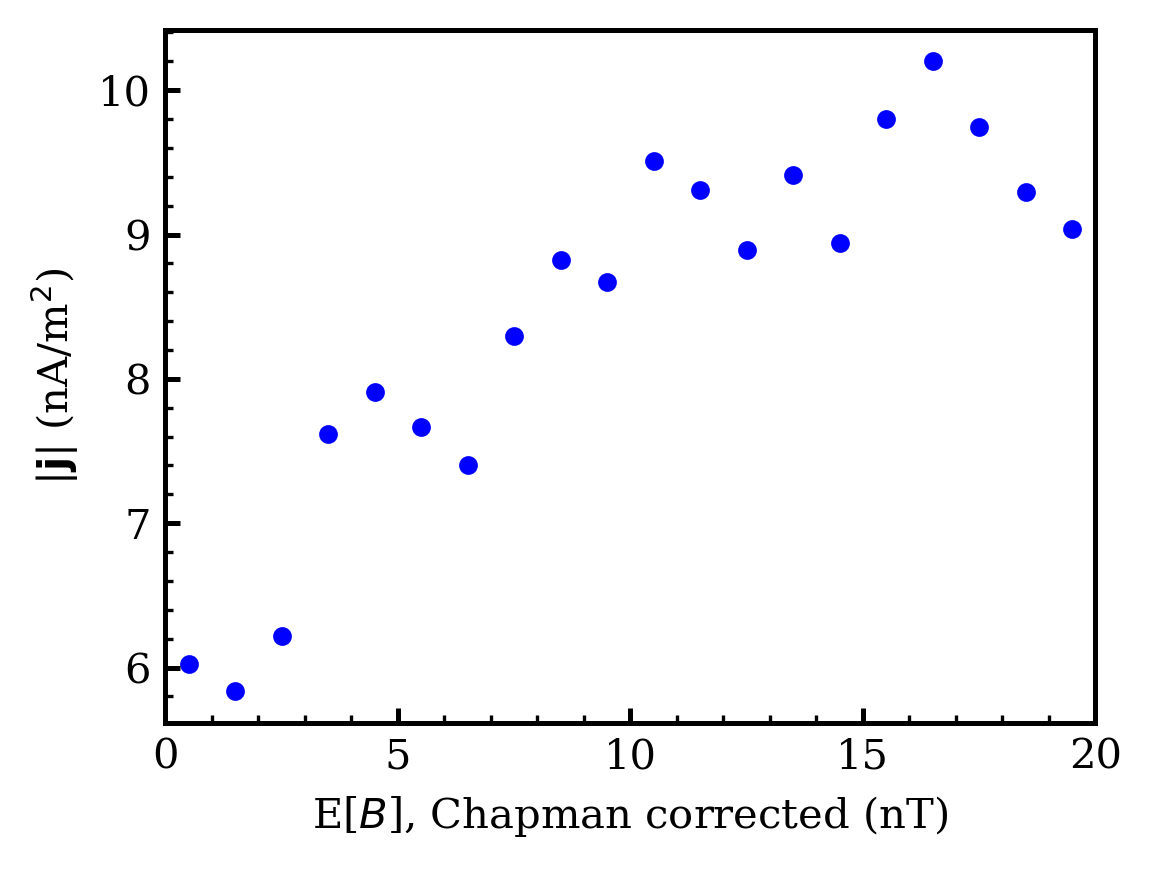

In [29]:
print(B_scaled.shape, J.shape)

plt.figure()
B_bins = np.arange(0,40,1)
J_means = []
J_std = []
for i in range(len(B_bins)-1):
    bin_mask = (B_scaled >= B_bins[i]) & (B_scaled < B_bins[i+1])
    J_mean = np.mean(J[bin_mask])
    J_means.append(J_mean)
    J_std.append(np.std(J[bin_mask]))
plt.hist(B_scaled, bins=B_bins, color='lightgray', alpha=0.5, density=True)
plt.xlabel(r'E[$B$] (nT)')
plt.ylabel('Density')
plt.savefig('figures/rotation_avg/B_chapman_density_rotation_avg_4seasons.pdf')

plt.figure()
# plt.errorbar(B_bins[:-1]+0.5, J_means, yerr=J_std, fmt='o', color='blue')
plt.scatter(B_bins[:-1]+0.5, J_means, color='blue')
plt.xlim(0,20)
plt.xlabel(r'E[$B$], Chapman corrected (nT)')
plt.ylabel(r'|$\mathbf{j}$| (nA/m$^2$)')
plt.savefig('figures/rotation_avg/Jtotal_vs_B_chapman_rotation_avg_4seasons_max20.pdf')

B_bins = B_bins[:20]
J_means = J_means[:20]
corr = np.corrcoef(B_bins, J_means)[0,1]
print(f'Correlation coefficient between J and B crustal (Chapman corrected) up to 20 nT: {corr}')

### wind speed vs current analysis

In [41]:
print(300/3.6)

83.33333333333333


In [29]:
# rigid_body_speed = (3393.5+150)*1e3*2*3.1415/(24*3600)  # m/s
n = 7e3  # cm^-3
n = n*1e6  # m^-3
e = 1.602e-19  # elementary charge, C
J = 10*1e-9  # A/m^2
u = (J/(n*e))*3/2 # m/s
print((3/2)*1e-9/(n*e))
print('Estimated neutral wind speed u = ', u, 'm/s')

1.3376136971642592
Estimated neutral wind speed u =  13.376136971642588 m/s


In [49]:
# elementary mass
m = 9.11e-31  # kg
B = 10*1e-9  # T
gyro_freq = e*B/m  # rad/s
print('Gyro frequency = ', gyro_freq, 'rad/s')
# in s-1:
print('Gyro frequency = ', gyro_freq/(2*np.pi), 'Hz')

Gyro frequency =  1758.5071350164656 rad/s
Gyro frequency =  279.8751030002375 Hz


In [6]:
print(119*1000/12)

9916.666666666666


### L-curve analysis for smoothness reg tuning

In [ ]:
lambdas = np.logspace(-8,11,num=20)

lambdas_true = []
mses = []
smoothness = []
validations = []

for l in lambdas:
    # folder_formats = [
    #     f'models/reg_test_flawed/PINN_ext_smoothness_reg_{l:.0e}',
    #     f'models/reg_test_flawed/PINN_ext_smoothness_reg_{l:.0f}',
    #     f'models/reg_test_flawed/PINN_ext_smoothness_reg_{l}'
    # ]
    # for folder_name in folder_formats:
    #     try:
    #         mses.append(np.load(f'{folder_name}/training_history.npy')[-1])
    #         smoothness.append(np.load(f'{folder_name}/smoothness_history.npy')[-1])
    #         # validations.append(np.load(f'{folder_name}/val_loss_hist.npy')[-1])
    #         lambdas_true.append(l)
    #         break
    #     except:
    #         continue
    if l == 1e9:
        continue
    folder_name = f'models/PINN_ext_smoothness_reg_{l:.0e}'
    try:
        mses.append(np.load(f'{folder_name}/training_history.npy')[-1])
        smoothness.append(np.load(f'{folder_name}/smoothness_history.npy')[-1])
        lambdas_true.append(l)
    except:
        continue
    

print(len(mses), 'models')
cmap = cmc.berlin(np.linspace(0, 1, len(lambdas_true)))
plt.figure(figsize=(5,4))
plt.plot(smoothness, mses, color = 'k', linewidth = 0.9, linestyle = '--')
for i in range(len(lambdas_true)):
    plt.scatter(smoothness[i], mses[i], label=f'{lambdas_true[i]:.0e}', c=cmap[i])
plt.xlabel('Roughness')
plt.ylabel('MSE')
plt.legend(loc=1, ncols=1,title='Smoothness lambda')
plt.tight_layout()
plt.show()
plt.close()

### L-curve analysis for L1 penalty tuning

In [ ]:
train_hist = np.load('models/PINN_ext_model_18/training_history.npy')
m, c = ut.slope(train_hist, 10)
print(f'Slope: {m}')

In [ ]:
print(5e2)

In [ ]:
lambdas = [1e-7, 5e-7, 1e-6, 2e-6, 5e-6, 7e-6, 1e-5]
models =  [    27, 29, 19,   26,   23,   280, 21]
mses = []
l1s = []
for model in models:
    try:
        mses.append(np.load(f'models/PINN_ext_model_{model}/training_history.npy')[-1])
        l1s.append(np.load(f'models/PINN_ext_model_{model}/l1_history.npy')[-1])
    except:
        mses.append(None)
        l1s.append(None)

condition = np.array([i is not None for i in mses])
print(sum(condition))
print(condition)
mses = np.array(mses)[condition]
l1s = np.array(l1s)[condition]
lambdas = np.array(lambdas)[condition]

cmap = cmc.berlin(np.linspace(0, 1, len(lambdas)))
# plt.plot(l1s, mses, color = 'k')
for i in range(len(mses)):
    plt.scatter(l1s[i], mses[i], label=lambdas[i], c=cmap[i])
plt.xlabel('L1')
plt.ylabel('MSE')
plt.legend(loc=1, ncols=2,title='L1 lambda')
plt.show()
plt.close()

### ensemble of models

In [ ]:
tensor_a = torch.tensor([[1,2,3],[4,5,6]], dtype=torch.float32)
tensor_b = tensor_a.clone()
tensor_c = tensor_a.clone()
# tensor_b = torch.tensor([4,5,6], dtype=torch.float32)
# tensor_c = torch.tensor([7,8,9], dtype=torch.float32)
tensor_list = torch.vstack((tensor_a,tensor_b))
tensor_list = torch.vstack((tensor_list,tensor_c))
print(tensor_list)
tensor_mean = torch.mean(tensor_list, dim = 0)
print(tensor_mean)


In [ ]:
models = [1,3,6,10,11,14]
epochs = [715,9325,"last","last","last","last"]
for model,epoch in zip(models,epochs):
    df = pd.read_csv(f'predictions/PINN_MSO_model{model}_epoch{epoch}_150km_fibonacci.csv')
    if model == 1:
        df_sum = df.copy()
    else:
        df_sum[['Bx','By','Bz','Jx','Jy','Jz','Br','Bt','Bp','Jr','Jt','Jp']] += df[['Bx','By','Bz','Jx','Jy','Jz','Br','Bt','Bp','Jr','Jt','Jp']]

df_sum[['Bx','By','Bz','Jx','Jy','Jz','Br','Bt','Bp','Jr','Jt','Jp']] /= len(models)

df_sum.to_csv('predictions/PINN_MSO_150km_models_1_3_6_10_11_14.csv')

### Hyperparameter tuning / training analysis

In [ ]:
print(np.arange(1,2))

In [ ]:
num_hidden_layers=3,
num_neurons_per_layer=32,
num_neurons = np.ones(num_hidden_layers, dtype=int)*num_neurons_per_layer
print(num_neurons)

In [ ]:
bs = 3
train_hist = np.load(f'models/PINN_ext_bootstrap_{bs}/val_loss_hist.npy')
plt.plot(train_hist)
plt.yscale('log')
plt.grid(axis='both',which='both')
# plt.ylim([train_hist[0],6.02933*1e1])
# plt.ylim([60.2,60.4])

### Calculator

In [ ]:
input = torch.load('data/position_mso.pt')
print(f'input mean = {torch.mean(input)}, std = {torch.std(input)}')
alt = torch.load('data/position_pc.pt')[:,0]
alt = alt.unsqueeze(1)
print(f'Alt mean = {torch.mean(alt)}, std = {torch.std(alt)}')
crustal_field_mso = torch.load('data/crustal_field_mso.pt')
observation_mso = torch.load('data/observation_mso.pt')
target = observation_mso - crustal_field_mso
print(f'Target mean = {torch.mean(target)} std = {torch.std(target)}')

### File conversion testing

In [ ]:
model_params = np.load('models/TEST_PINN_ext_model_8/model_params.npy', allow_pickle=True).item()
print(model_params['alt_std'])

In [ ]:
crustal_field_mso = torch.load('data/crustal_field_mso.pt')
observation_mso = torch.load('data/observation_mso.pt')
target = observation_mso - crustal_field_mso
print(len(target))
# print('Min and max of target: ', torch.min(target), torch.max(target))
# print('Mean and std of target: ', torch.mean(target), torch.std(target))
# randomly downsample target to compute quantiles faster
# target_downsampled = target[torch.randperm(target.size(0))[:10000]]
# print('q1, median, q3 of target: ', torch.quantile(target_downsampled,0.25), torch.median(target_downsampled), torch.quantile(target_downsampled,0.75))
# print('IQR*1.5: ', 1.5*(torch.quantile(target_downsampled,0.75)-torch.quantile(target_downsampled,0.25)))

condition = (target <= 30) & (target >= -30)
condition = torch.any(condition, dim=1)
target = target[condition]
print(len(target))


In [ ]:
print(0.25*3393.5)

In [ ]:
input_1 = torch.load('data/position_mso_spherical.pt')
alt_1 = input_1[:,0].unsqueeze(1)
# input_2 = torch.load('data/position_pc.pt')
# alt_2 = input_2[:,0].unsqueeze(1)
# print(torch.sum(abs(alt_1-alt_2)))
id = np.random.randint(len(alt_1),size = 100000)
alt_1 = alt_1[id]
print(max(alt_1))

In [ ]:
input = torch.load('data/position_mso.pt')
n = len(input)
alt = torch.load('data/position_pc.pt')[:,0]
condition = alt <= 600 #km, only low altitude!
input = input[condition]
alt = alt[condition]

print(f'Data size : {len(input)*100/n:.2f} %')
print(f'Mean value : {torch.mean(input)}')
print(f'Standard deviation : {torch.std(input)}')
print('')
print(f'Mean alt : {torch.mean(alt)}')
print(f'Standard deviation alt : {torch.std(alt)}')


In [ ]:
print(np.log(21730))

In [ ]:
df = pd.read_parquet('data/MAVEN_MSO_data.parquet', columns=['PC Bx data', 'PC By data', 'PC Bz data'])
# df['SS colat'] = 90 - df['SS lat']
# df['sin_colat'] = np.sin(np.radians(df['SS colat']))
# df['cos_colat'] = np.cos(np.radians(df['SS colat']))
# df['sin_lon'] = np.sin(np.radians(df['SS lon']))
# df['cos_lon'] = np.cos(np.radians(df['SS lon']))
# df = df.drop(columns=['SS lat','SS lon','SS colat'])
# print(df.head())
observation_pc = torch.tensor(df.values, dtype=torch.float32)
# torch.save(observation_pc, 'data/observation_pc.pt')



In [ ]:
print(torch.mean(alt))

In [ ]:
# test position file
position = torch.load('data/position_pc.pt')
position_10000_random_picks = position[torch.randperm(position.size(0))[:10000]]
print(min(position_10000_random_picks[:, 0]), max(position_10000_random_picks[:, 0]))
print(min(position_10000_random_picks[:, 1]), max(position_10000_random_picks[:, 1]))
print(min(position_10000_random_picks[:, 2]), max(position_10000_random_picks[:, 2]))

In [ ]:
# compare crustal field from L19 and D25 (only scalar)
df = dc.format_sample()
df = df[['BL PC Bx','BL PC By','BL PC Bz']].values
crustal_field_pc = torch.load('data/crustal_field_pc.pt')
crustal_field_pc = crustal_field_pc[:len(df)]
df = torch.tensor(df, dtype=torch.float32)
B_l19 = np.sqrt(df[:,0]**2 + df[:,1]**2 + df[:,2]**2)
B_D25 = np.sqrt(crustal_field_pc[:,0]**2 + crustal_field_pc[:,1]**2 + crustal_field_pc[:,2]**2)
mse = torch.mean((B_l19 - B_D25)**2)
print("MSE crustal field (nT^2): ", mse.item())

In [ ]:
df = dc.format_sample()
df = df[['BL SS Bx','BL SS By','BL SS Bz']].values
crustal_field_mso = torch.load('data/crustal_field_mso.pt')
crustal_field_mso = crustal_field_mso[:len(df)]
df = torch.tensor(df, dtype=torch.float32)

mse = torch.mean((crustal_field_mso-df)**2)
print("MSE crustal field (nT^2): ", mse.item())

### Curl tests

#### 2D curl in cartesian coordinates

In [ ]:
x0 = np.arange(-10, 10, 1.0)
y0 = x0.copy()
X,Y = np.meshgrid(x0, y0)
x,y = X.ravel(), Y.ravel()
plt.figure()
plt.quiver(X,Y,Y,-X)
plt.show()


In [ ]:
def tensor(t):
    return torch.tensor(t,dtype = torch.float32)


Input = torch.stack((tensor(x), tensor(y) ), dim=1)
Input = torch.tensor(Input,requires_grad=True)
Output1 = torch.zeros_like(Input)
Output1[:,0] = Input[:,1]
Output1[:,1] = -Input[:,0]
# gradient = torch.ones_like(Input)
Output1.sum().backward()
print(Input.grad.shape)

curl1 = Input.grad[:,0] - Input.grad[:,1]
print(torch.unique(curl1).item())

#### 3D curl in cartesian coordinates

In [ ]:
x0 = np.arange(-10, 10, 1.0)
y0 = x0.copy()
z0 = x0.copy()
X,Y,Z = np.meshgrid(x0, y0, z0)
x,y,z = X.ravel(), Y.ravel(), Z.ravel()
Input = torch.stack((tensor(x), tensor(y), tensor(z) ), dim=1)
Input.requires_grad=True

Output1 = torch.zeros_like(Input)
Output1[:,0] = Input[:,1] ** 3 - 9* Input[:,1]
Output1[:,1] = Input[:,0] ** 3 - 9* Input[:,0]
Output1[:,2] = 0


Output1[:,0].sum().backward(retain_graph=True)
dBx_dx = Input.grad[:,0].clone()
dBx_dy = Input.grad[:,1].clone()
dBx_dz = Input.grad[:,2].clone()

Input.grad.zero_()

Output1[:,1].sum().backward(retain_graph=True)
dBy_dx = Input.grad[:,0].clone()
dBy_dy = Input.grad[:,1].clone()
dBy_dz = Input.grad[:,2].clone()

Input.grad.zero_()

Output1[:,2].sum().backward(retain_graph=True)
dBz_dx = Input.grad[:,0].clone()
dBz_dy = Input.grad[:,1].clone()
dBz_dz = Input.grad[:,2].clone()

curl = torch.stack((dBz_dy - dBy_dz, dBx_dz - dBz_dx, dBy_dx - dBx_dy), dim=1)
cond = curl[:,2] > 0
print(curl[:,2][cond])

analytical_curl = torch.zeros_like(Input)
analytical_curl[:,0] = 0
analytical_curl[:,1] = 0
analytical_curl[:,2] = 3*Input[:,0]**2 - 3*Input[:,1]**2

print(analytical_curl[:,2][cond])



#### 3D curl(curl()) in cartesian coordinates

In [ ]:
def curl(Input, Output):
    
    Output[:,0].sum().backward(retain_graph=True)
    dBx_dx = Input.grad[:,0].clone()
    dBx_dy = Input.grad[:,1].clone()
    dBx_dz = Input.grad[:,2].clone()

    Input.grad.zero_()

    Output[:,1].sum().backward(retain_graph=True)
    dBy_dx = Input.grad[:,0].clone()
    dBy_dy = Input.grad[:,1].clone()
    dBy_dz = Input.grad[:,2].clone()

    Input.grad.zero_()

    Output[:,2].sum().backward(retain_graph=True)
    dBz_dx = Input.grad[:,0].clone()
    dBz_dy = Input.grad[:,1].clone()
    dBz_dz = Input.grad[:,2].clone()

    curl = torch.stack((dBz_dy - dBy_dz, dBx_dz - dBz_dx, dBy_dx - dBx_dy), dim=1)
    return curl



x0 = np.arange(-10, 10, 1.0)
y0 = x0.copy()
z0 = x0.copy()
X,Y,Z = np.meshgrid(x0, y0, z0)
x,y,z = X.ravel(), Y.ravel(), Z.ravel()
Input = torch.stack((tensor(x), tensor(y), tensor(z) ), dim=1)
Input.requires_grad = True
Output = torch.zeros_like(Input)
Output[:,0] = Input[:,1] ** 3 - 9* Input[:,1]
Output[:,1] = Input[:,0] ** 3 - 9* Input[:,0]
Output[:,2] = 0

curl1 = curl(Input, Output)

# checking results
tensors_combined = torch.concatenate((curl1,Input),dim=1)
tensors_combined = tensors_combined[cond].detach().numpy()
print(len(tensors_combined))
for i in range(len(tensors_combined)):
    if i == 0:
        print(tensors_combined[i])
        print(f'Analytical solution : {3*(tensors_combined[i,3]**2-tensors_combined[i,4]**2)}')
        
    elif (tensors_combined[i,2] == tensors_combined[i-1,2]):
        continue
    else:
        print(tensors_combined[i])
        print(f'Analytical solution : {3*(tensors_combined[i,3]**2-tensors_combined[i,4]**2)}')
        




In [ ]:
def curl_differentiable(Input, Output):
    """
    Compute curl while maintaining computational graph for higher-order derivatives
    """
    # Use torch.autograd.grad instead of .backward() to maintain graph
    
    # Compute all partial derivatives using the same logic as the working version
    # ∂Bx/∂(x,y,z)

    grad_Bx = torch.autograd.grad(Output[:,0].sum(), Input, create_graph=True, retain_graph=True)[0]
    dBx_dx, dBx_dy, dBx_dz = grad_Bx[:,0], grad_Bx[:,1], grad_Bx[:,2]
    
    # ∂By/∂(x,y,z)  
    grad_By = torch.autograd.grad(Output[:,1].sum(), Input, create_graph=True, retain_graph=True)[0]
    dBy_dx, dBy_dy, dBy_dz = grad_By[:,0], grad_By[:,1], grad_By[:,2]
    
    # ∂Bz/∂(x,y,z)
    grad_Bz = torch.autograd.grad(Output[:,2].sum(), Input, create_graph=True, retain_graph=True)[0] 
    dBz_dx, dBz_dy, dBz_dz = grad_Bz[:,0], grad_Bz[:,1], grad_Bz[:,2]
    
    # Curl formula: (∂Bz/∂y - ∂By/∂z, ∂Bx/∂z - ∂Bz/∂x, ∂By/∂x - ∂Bx/∂y)
    curl_x = dBz_dy - dBy_dz
    curl_y = dBx_dz - dBz_dx  
    curl_z = dBy_dx - dBx_dy
    
    return torch.stack((curl_x, curl_y, curl_z), dim=1)

# Test and compare both versions
x0 = np.arange(-10, 10, 1.0)
y0 = x0.copy()
z0 = x0.copy()
X,Y,Z = np.meshgrid(x0, y0, z0)
x,y,z = X.ravel(), Y.ravel(), Z.ravel()
Input_new = torch.stack((tensor(x), tensor(y), tensor(z)), dim=1)
Input_new.requires_grad_(True)

Output_new = torch.zeros_like(Input_new)
Output_new[:,0] = Input_new[:,1] ** 3 - 9* Input_new[:,1]
Output_new[:,1] = Input_new[:,0] ** 3 - 9* Input_new[:,0]  
Output_new[:,2] = 0

print("Computing curl with differentiable version...")
curl1_diff = curl_differentiable(Input_new, Output_new)
# check_result(curl1_diff, Input_new)

curl2_diff = curl_differentiable(Input_new, curl1_diff)







tensors_combined = torch.concatenate((curl2_diff,Input),dim=1)
tensors_combined = tensors_combined.detach().numpy()
print(len(tensors_combined))
for i in range(len(tensors_combined)):
    if i == 0:
        print(tensors_combined[i])
        print(f'Analytical solution : x = {-6*tensors_combined[i,4]}, y = {-6*tensors_combined[i,3]}')
    elif (tensors_combined[i,0:2] == tensors_combined[i-1,0:2]).all():
        continue
    else:
        print(tensors_combined[i])
        print(f'Analytical solution : x = {-6*tensors_combined[i,4]}, y = {-6*tensors_combined[i,3]}')
